In [30]:
import yaml, torch, sys
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import random as random
import re
import torch, json, random, os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from torch.utils.data import random_split
from types import SimpleNamespace
#add more packages here
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [28]:

sys.path.insert(0, '../../')
from utils.train_model import set_seed, get_device

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_02.yaml') as f:
    config.update(yaml.safe_load(f))
    
    

def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

config = to_namespace(config)

set_seed(config.seed)
device = get_device()

RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)


data_dir = Path("./EX_01/Raw/")

[device] using cuda


# Context.

This is the second experiment of the first epic, whose purpose is expand on the last experiment. The purpose of EX_02 is to take our first stab at a competent model. 

We are extending to a 4-channel input, penalizing the model for affecting the 3-channels of background and thus encouraging it to alter only the glyph, which will be represented by only a single channel as we're still using the MNIST dataset. In this experiment, we'll extend the CNN from the simple one that was used before, but will not be using more complicated model structures yet. 

As with the previous experiment, we'll only use a fixed vertical blur for all glyphs. Future experiments may try other blurs.

# Hypothesis

Thus, our formal hypothesis is as follows:


A 3-block CNN can outperform a single block CNN in terms of both pre- and post- confidence delta. We also hope that it will do this by learning to expand the glyph pixels rather than just selectively drop pixels. 

# Implementation 



# Data

Each background is a sythentically created gradient between two random colors, in a 28x28p image. Each image will be a randomly selected item of the MNIST dataset.

For right now, we're just going to plop the mnist image (in the code called "i" or "image") over the gradient background (in the code called "b" or "background"), forming a 4-channel image (called "c" or "comp" in the code). Future experiments should expand on this by learning other combinations. 

# Notes 

# Code

In [29]:
#prep



def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

In [31]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)


class ex02a(Dataset):
    def __init__(self, batch_size, transform=None):
        self.pairings = pd.read_csv(Path(config.csv_path))
        self.gradients_dir = Path(config.grad_dir)
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
                                        transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        if not isinstance(ann["gradient_path"], str):
            raise Exception ("huhhh")
        b_img_path =  "../EX_01/" + ann["gradient_path"]
        b = self.transform(Image.open(b_img_path).convert("RGB")) 
        i, lab = self.mnist[int(ann["mnist_idx"])]

        comp = torch.cat([b, i], dim=0)  # (4, H, W)
        return comp, lab
    
    def __getitems__(self, indices):
        return [self[i] for i in indices]

ex02a_trainset = ex02a(batch_size = config.batch_size)
# ex02a_trainloader = DataLoader(ex02a_trainset, batch_size=config.batch_size, shuffle=True)
# ex02a_valloader = DataLoader(ex02a_trainset, batch_size=config.batch_size, shuffle=True)



n = len(ex02a_trainset)
train_size = int(0.9 * n)
val_size   = n - train_size

train_set, val_set = random_split(ex02a_trainset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))

ex02a_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex02a_valloader   = DataLoader(val_set,   batch_size=config.batch_size)


In [16]:
#change later prob
# indices = random.sample(range(len(ex02a_trainset)), 256*25)
# subset  = torch.utils.data.Subset(ex02a_trainset, indices)
# ex02a_trainloader = DataLoader(subset, batch_size=config.batch_size) #for testin
# ex02a_valloader = DataLoader(subset, batch_size=config.batch_size) 

In [32]:
#model
#shorthand for each cnn block
def conv_block(in_ch, out_ch, kernel, pool=True, dropout = True):
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(),
        nn.Conv2d(out_ch, out_ch, kernel, padding=kernel//2),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    if dropout: 
        layers.append(nn.Dropout(config.variants.a.dropout_rate))
    return nn.Sequential(*layers)

class threeBlockCNN4Channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = conv_block(4, 64, 3, pool=False, dropout=False)
        self.block2 = conv_block(64, 128, 3, pool=False, dropout=True)
        self.out    = nn.Conv2d(128, 1, 1)
    
    def forward(self, x):     
        x = self.block1(x)
        x  = self.block2(x) #will output a batchsize, 64, isize, isize
        return torch.sigmoid(self.out(x)) 

    
def ex02a_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch
    b, i  = comp[:, :3], comp[:, 3:]

    mask = model(comp) #model takes in a 4 channel, outputs a 1 channel mask for the image. it'll learn to exploit the image when possible (we'll change the model strucutre more to do more on this later)
    masked_digit = i * mask
    comp  = additive_combine(b, masked_digit) 
    conf_pre, pred_pre  = m_classify_3d_with_conf(comp, label)
    
    blurred = box_blur(comp)
    conf_post, pred_post = m_classify_3d_with_conf(blurred, label)
    delta_vis = (config.variants.a.alpha * conf_pre) + (config.variants.a.beta * conf_post)
    delta_vis = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    sparsity_loss = config.variants.a.sparse_lambda * mask.mean() #added sparcity to encourage the model to do non-intrusive masks
    loss = sparsity_loss + delta_vis 
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "conf_post": conf_post.mean().item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss


In [33]:


# ── RUN ───────────────────────────────────────────────────────────────────────
ex02a_info = {
    "exp_id":      "EX_02a",
    "epochs":      10,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

model_2a = threeBlockCNN4Channel()
optimizer = torch.optim.Adam(model_2a.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../EX_01/Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
b_model.eval()

    
# returns conf, predicted
def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

In [34]:
run_experiment(
    model=model_2a,
    optimizer=optimizer,
    loss_fn=ex02a_loss_fn,
    train_loader=ex02a_trainloader,
    val_loader=ex02a_valloader,
    config=ex02a_info,
    log_to=ex02a_info["log_to"],
)

[device] using cuda


IOPub message rate exceeded.        | 252/2110 [00:36<04:33,  6.80it/s, loss=-0.0694] 
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                       

conf_post,▁▄▅▆▇▇█▇██
conf_pre,█▇▆▅▅▄▄▁▂▁
delta_vis,█▅▄▃▂▂▂▂▁▁
epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▂▂▁▁▁
val_loss,█▅▄▃▂▂▂▂▁▁
conf_post,0.27023
conf_pre,0.03272
delta_vis,-0.10361
epoch,10
train_loss,-0.10178


threeBlockCNN4Channel(
  (block1): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
  )
  (out): Conv2d(128, 1, kernel_size=(1, 1), stride=(1, 1))
)

# Results

=====EX_02_A Model Pictures =========


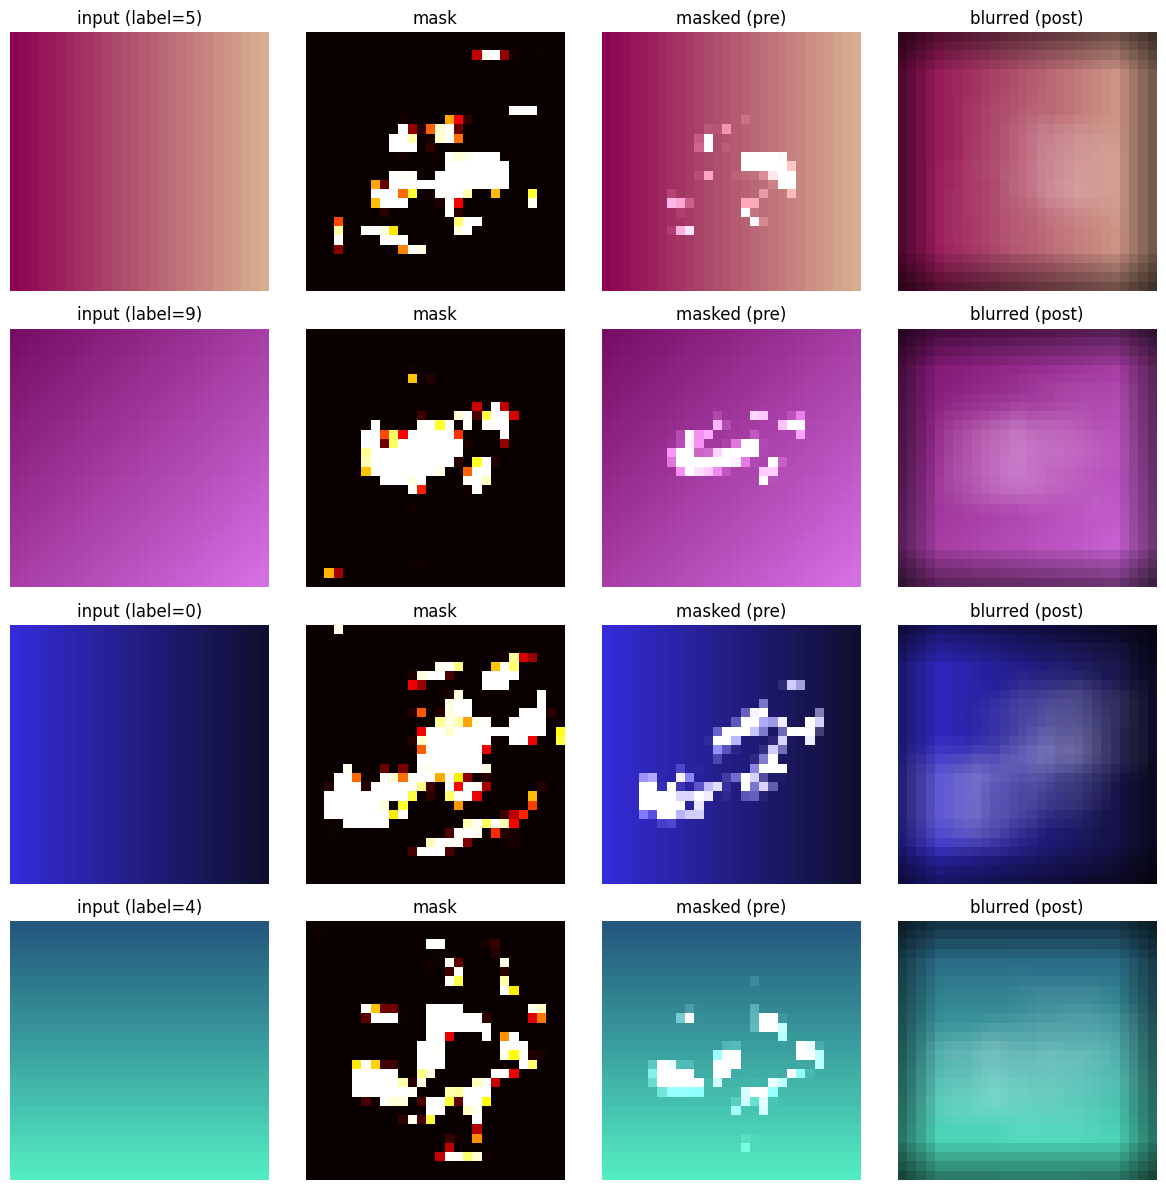

In [36]:
def show_masks(model, dataset, device, variation, n=4):
    fig, axes = plt.subplots(n, 4, figsize=(12, n*3))
    indices = random.sample(range(len(dataset)), n)
    
    for row, idx in enumerate(indices):
        comp, label = dataset[idx]
        comp_in = comp.unsqueeze(0).to(device)
        b = comp[:3]
        
        with torch.no_grad():
            mask          = model(comp_in)                          # (1, 1, H, W)
            masked_digit  = comp_in[:, 3:] * mask
            composite     = additive_combine(comp_in[:, :3], masked_digit)
            blurred       = box_blur(composite)

        axes[row, 0].imshow(b.permute(1,2,0))
        axes[row, 0].set_title(f"input (label={label})")
        
        axes[row, 1].imshow(mask.squeeze().cpu(), cmap="hot")
        axes[row, 1].set_title("mask")
        
        axes[row, 2].imshow(composite.squeeze(0).cpu().permute(1,2,0))
        axes[row, 2].set_title("masked (pre)")
        
        axes[row, 3].imshow(blurred.squeeze(0).cpu().permute(1,2,0))
        axes[row, 3].set_title("blurred (post)")
        
        for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(f"Model/{variation}/EX_01{variation}_samples.png")
    plt.show()


print("=====EX_02_A Model Pictures =========")
show_masks(model_2a, ex02a_trainset, device, "A")

#Evaluation¶
We got a overall accuracy of like 0.1 with the original run of this, so i turned down the sparcity lambda a ton, and am running with the full dataset on the gpu. We might need a better penalty than the sparcity - something for contingous runs or something? In any case, the model is not learning to enlarge the image at all, to make use of the vertical blur, so we need to try to force it to do that somehow. 
A tiny bit better with the full dataset - we're up to a 0.03272 post and 0.27023 pre. We're now in the wrong direction but like it's better than 0 in each case. It definitely seems like this proves that there is no way to get what we want with a selective mask. in any case they more it trains its not helping it at all

# Previous "Next steps"
✓Try with a steeper alpha than a beta, since we've realized we don't care about them equally
Try {-0.9, .1}, {-.75, 0.25}, and {-0.6, -0.4}
Try with larger images, embedding the MNIST digit anywhere in the image.
Try a more descriptive mask technique:
✓visualize some masks to see what it's learning (seems it likes to blur)
try expanding the image - especially with a linear blur,

# Next steps